In [3]:
import pandas as pd
import numpy as np
import io
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import glob
import os,shutil
import regex as re

In [4]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-whitegrid'])
WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
    "hatch.color": '#eeeeee',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "Times New Roman",
#     "text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    # Make the label fonts a little smaller
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 1,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)
plt.rcParams['axes.edgecolor']='#333F4B'
plt.rcParams['axes.linewidth']=0.8

linestyle_tuple = [
     ('solid',        (0, ())),
     ('dotted',                (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]

/tmp/ipykernel_435053/1232656171.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['ggplot', 'seaborn-whitegrid'])


In [5]:
def preprocess_result(sample_method):
    df = pd.read_csv(f"/ANOVA/ExtensiveEval/results/ANOVA/RESULT_{sample_method}.csv")
    # df = pd.read_csv(f"/ANOVA/RESULT_{sample_method}.csv")
    if sample_method == "stratified":
        df.alg = df.apply(lambda x: x.alg.replace(f"_{x.stratified_term}",""), axis=1)
    df = df[df.alg.isin(['aria-Aria_tpcc', 'calvin-Calvin_tpcc', 'cicada-Cicada_ycsb',
        'drtm_tpcc', 'gam_tpcc', 'herd_ycsb', 'janus-Janus_tpcc', 'mysql_tpcc', 
        'silo-Silo_tpcc', 'silo_ycsb', 'star_tpcc', 'star_ycsb','tapir_ycsb','postgresql_tpcc',
        "calvin-Calvin-comp_tpcc","aria-Calvin-comp_tpcc"])]
    # ,"silo_vs_partitionedstore","janus_vs_2pl"])]
    rename_alg = {
        'aria-Aria_tpcc':"Aria-TPC-C", 'calvin-Calvin_tpcc':"Calvin-TPC-C", 'cicada-Cicada_ycsb':"Cicada-YCSB",
        'drtm_tpcc':"DrTM-TPC-C", 'gam_tpcc':"GAM-TPC-C", 'herd_ycsb':"HERD-YCSB", 'janus-Janus_tpcc':"Janus-TPC-C", 'mysql_tpcc':"MySQL-TPC-C", 
        'silo-Silo_tpcc':"Silo-TPC-C", 'silo_ycsb':"Silo-YCSB", 'star_tpcc':"Star-TPC-C", 'star_ycsb':"Star-YCSB",'postgresql_tpcc':"PostgreSQL-TPC-C",
        'tapir_ycsb':'TAPIR-YCSB',"silo_vs_partitionedstore":"Silo/PartitionedStore-TPC-C","janus_vs_2pl":"Janus/2PL-TPC-C",
        "aria-Calvin-comp_tpcc":"Calvin(Aria)-TPC-C","calvin-Calvin-comp_tpcc":"Calvin(original)-TPC-C"} 
    df['alg'] = df['alg'].apply(lambda x:rename_alg[x])
    df["num_of_terms_changed"] *= 100
    df["num_turning_mismatch"] *= 100
    df['sample_ratio'] = df['sample_ratio'].apply(pd.to_numeric)
    df['random'] = df['random'].apply(pd.to_numeric)
    df['split'] = df['split'].apply(pd.to_numeric)
    rename_alg_rev = {v: k for k, v in rename_alg.items()}
    df['sample_method'] = sample_method
    return df

In [12]:
df = pd.concat([preprocess_result(sample_method) for sample_method in ["random","stratified","balance","dist-aware"]],ignore_index=True)

In [ ]:
# out_base = f"/ANOVA/plots/anova_all_metrics"

# if not os.path.exists(out_base):
#     os.makedirs(out_base)


# for alg_name in df.alg.unique():
#     fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(5,9),constrained_layout=True)
#     sns.lineplot(data=df[df.alg==alg_name],x="sample_ratio",y="num_turning_mismatch",estimator="median",errorbar=("pi",60), err_style="bars",ax=ax1,markers=True,dashes=True, hue="sample_method",style = "sample_method")
#     ax1.set_xlabel("sample ratio")
#     ax1.set_ylabel(None)
#     ax1.set_title("\%Knee/Turning Points Mismatch")

#     sns.lineplot(data=df[df.alg==alg_name],x="sample_ratio",y="num_of_terms_changed",estimator="median",errorbar=("pi",60), err_style="bars",ax=ax2,markers=True,dashes=True, hue="sample_method",style = "sample_method")
#     ax2.set_xlabel("sample ratio")
#     ax2.set_ylabel(None)
#     ax2.set_title("\%Significant Terms Changed")

#     sns.lineplot(data=df[df.alg==alg_name],x="sample_ratio",y="r2_unsample",estimator="median",errorbar=("pi",60), err_style="bars",ax=ax3,markers=True,dashes=True, hue="sample_method",style = "sample_method")
#     ax3.set_xlabel("sample ratio")
#     ax3.set_ylabel(None)
#     ax3.set_title("unsampled set R2")   
    
#     ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,numpoints=2)
#     ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,numpoints=2)
#     ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,numpoints=2)
    
#     fig.suptitle(f"{alg_name}")
#     fig.savefig(f"{out_base}/{alg_name}.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

In [98]:
all_algs

array(['Calvin-TPC-C', 'Silo-YCSB', 'TAPIR-YCSB', 'HERD-YCSB',
       'GAM-TPC-C', 'Silo-TPC-C', 'Cicada-YCSB', 'Star-YCSB',
       'DrTM-TPC-C', 'MySQL-TPC-C', 'Janus-TPC-C', 'PostgreSQL-TPC-C',
       'Aria-TPC-C', 'Star-TPC-C'], dtype=object)

In [25]:
df.groupby(by=["alg","sample_method","sample_ratio","random"])["r2_unsample"].min().reset_index()

,alg,sample_method,sample_ratio,random,r2_unsample
0,Aria-TPC-C,balance,0.05,0,0.820233
1,Aria-TPC-C,balance,0.05,1,0.188420
2,Aria-TPC-C,balance,0.05,2,0.683201
3,Aria-TPC-C,balance,0.05,3,0.570767
4,Aria-TPC-C,balance,0.05,4,0.370672
...,...,...,...,...,...
9181,TAPIR-YCSB,stratified,0.95,5,0.909598
9182,TAPIR-YCSB,stratified,0.95,6,0.903707
9183,TAPIR-YCSB,stratified,0.95,7,0.914381
9184,TAPIR-YCSB,stratified,0.95,8,0.917332


In [30]:
r2_unsamples[r2_unsamples.alg==alg_name].r2_unsample.min()

-4.532884884262398

In [35]:
r2_unsamples[r2_unsamples.alg==alg_name].groupby(by=["sample_method","sample_ratio"])["r2_unsample"].quantile(0.2).min()

-11.44431160778307

In [ ]:
out_base = f"/ANOVA/plots/anova_r2"
if not os.path.exists(out_base):
    os.makedirs(out_base)

fig_size_one = set_size(WIDTH)
r2_unsamples = df.groupby(by=["alg","sample_method","sample_ratio","random"])["r2_unsample"].min().reset_index()

# fig, axs = plt.subplots(4, 3, figsize=(fig_size_one[0]*3,fig_size_one[1]*4),constrained_layout=True)
all_algs = df.alg.unique()
x_labels = [f"{i:.2f}" for i in np.arange(0.05, 1, 0.05)]
for idx, alg_name in enumerate(all_algs):
    # ax = axs[idx//3][idx%3]
    fig, ax = plt.subplots(1, 1, figsize=fig_size_one,constrained_layout=True)
    sns.lineplot(data=r2_unsamples[r2_unsamples.alg==alg_name],
                 x="sample_ratio",
                 y="r2_unsample",
                 estimator="median",
                 palette="Set1",
                 errorbar=("pi",60), 
                 err_style="bars",
                 ax=ax,
                 dashes=True, 
                 hue="sample_method",
                 style = "sample_method",
                 ms = 1, mew = 2, 
                 linewidth=1.0)
    ax.set_xticks(np.arange(0.05, 1, 0.05))
    ax.set_xticklabels(x_labels,rotation=30)
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("P50 of R2 Scores +/- to P80 and P20")
    min_r2 = r2_unsamples[r2_unsamples.alg==alg_name].groupby(by=["sample_method","sample_ratio"])["r2_unsample"].quantile(0.2).min()
    # if min_r2 < -5:
    #     ax.set_ylim([-5,1])
    # elif min_r2 < 0:
    #     ax.set_ylim([-1,1])
    # elif min_r2 < 0.4:
    if min_r2 < 0.5:
        ax.set_ylim([0,1.1])
    else:
        ax.set_ylim([0.5,1.1])
    # ax.set_ylim([-1,1])
    ax.legend(loc='upper left', bbox_to_anchor=(0., 1.3, 0, .102), ncol=2, borderaxespad=0.,numpoints=2)
    fig.savefig(f"{out_base}/{alg_name}.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

# fig.savefig(f"{out_base}/anova_r2_unsample.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

In [54]:
alg_r2_unsample = r2_unsamples[r2_unsamples.alg==alg_name].groupby(by=["sample_method","sample_ratio"])["r2_unsample"].median().reset_index()

In [55]:
alg_r2_unsample 

,sample_method,sample_ratio,r2_unsample
0,balance,0.25,0.285504
1,balance,0.30,0.550790
2,balance,0.35,0.210708
3,balance,0.40,0.653421
4,balance,0.45,0.845003
...,...,...,...
56,stratified,0.75,0.916180
57,stratified,0.80,0.934158
58,stratified,0.85,0.947364
59,stratified,0.90,0.950215


In [60]:
alg_r2_unsample.loc[alg_r2_unsample['r2_unsample'] >= 0.9].groupby(by=["sample_method"])["sample_ratio"].min().idxmin()

'balance'

In [62]:
alg_r2_unsample

,sample_method,sample_ratio,r2_unsample
0,balance,0.05,-0.424177
1,balance,0.10,-0.163069
2,balance,0.15,0.328387
3,balance,0.20,0.511145
4,balance,0.25,0.506737
...,...,...,...
71,stratified,0.75,0.667258
72,stratified,0.80,0.697603
73,stratified,0.85,0.681897
74,stratified,0.90,0.670877


In [69]:
triggers = alg_r2_unsample.loc[alg_r2_unsample['r2_unsample'] >= 0.9].groupby(by=["sample_method"])["sample_ratio"].min()

In [70]:
triggers

sample_method
balance       0.55
dist-aware    0.60
random        0.60
stratified    0.70
Name: sample_ratio, dtype: float64

In [73]:
triggers[triggers == triggers.min()].index.to_list()

['balance']

In [83]:
min_list = triggers[triggers == triggers.min()].index.to_list()
alg_r2_unsample[(alg_r2_unsample.sample_ratio == triggers.min()) & (alg_r2_unsample.sample_method.isin(min_list))].sort_values(by=["r2_unsample"],ascending=False)['sample_method'].to_list()

['balance']

In [85]:
triggers

sample_method
balance       0.55
dist-aware    0.60
random        0.60
stratified    0.70
Name: sample_ratio, dtype: float64

In [86]:
min_list

['balance']

In [87]:
res

['balance']

In [89]:
r2_unsamples = df.groupby(by=["alg","sample_method","sample_ratio","random"])["r2_unsample"].min().reset_index()

# fig, axs = plt.subplots(4, 3, figsize=(fig_size_one[0]*3,fig_size_one[1]*4),constrained_layout=True)
all_algs = df.alg.unique()
x_labels = [f"{i:.2f}" for i in np.arange(0.05, 1, 0.05)]
for idx, alg_name in enumerate(all_algs):
    # ax = axs[idx//3][idx%3]
    alg_r2_unsample = r2_unsamples[r2_unsamples.alg==alg_name].groupby(by=["sample_method","sample_ratio"])["r2_unsample"].median().reset_index()
    print(alg_name)
    try:
        triggers = alg_r2_unsample.loc[alg_r2_unsample['r2_unsample'] >= 0.9].groupby(by=["sample_method"])["sample_ratio"].min()
        min_list = triggers[triggers == triggers.min()].index.to_list()
        res = alg_r2_unsample[(alg_r2_unsample.sample_ratio == triggers.min()) & (alg_r2_unsample.sample_method.isin(min_list))].sort_values(by=["r2_unsample"],ascending=False)['sample_method'].to_list()
        print(triggers.min())
        print(res)
    except:
        print("Did not reach")
    print("\n")

Calvin-TPC-C
nan
[]


Silo-YCSB
0.8
['random']


TAPIR-YCSB
0.55
['random']


HERD-YCSB
0.1
['balance', 'dist-aware', 'random', 'stratified']


GAM-TPC-C
nan
[]


Silo-TPC-C
0.7
['random', 'balance', 'stratified']


Cicada-YCSB
0.4
['dist-aware']


Star-YCSB
0.2
['dist-aware', 'random']


DrTM-TPC-C
nan
[]


MySQL-TPC-C
0.3
['balance', 'random']


Janus-TPC-C
nan
[]


PostgreSQL-TPC-C
0.2
['balance', 'random']


Aria-TPC-C
0.1
['balance', 'random', 'dist-aware', 'stratified']


Star-TPC-C
0.55
['balance']




In [39]:
df_random = preprocess_result("random")
all_algs = df_random.alg.unique()

In [40]:
r2_unsamples = df_random.groupby(by=["alg","sample_ratio","random"])["r2_unsample"].min()

In [41]:
r2_thresh_to_examine = [0.2,0.4,0.6,0.8,0.9,0.95]
rows = []
r2_unsamples = df_random.groupby(by=["alg","sample_ratio","random"])["r2_unsample"].min()
for alg in all_algs:
    if alg in  ["PostgreSQL-TPC-C"]:
        continue
    for random in range(10):
        for r2_thresh in r2_thresh_to_examine:
            min_r2_series = r2_unsamples.loc[alg,:,random]
            try:    
                min_sample_ratio = min_r2_series.loc[min_r2_series > r2_thresh].idxmin()
            except ValueError:
                # min_sample_ratio = min_r2_series.idxmax()
                continue
            row = df_random.loc[(df_random.alg==alg) & (df_random.random==random) & (df_random.sample_ratio==min_sample_ratio)].copy()
            # row = row.groupby(by=["alg","sample_ratio","random"])[["num_of_terms_changed","num_turning_mismatch"]].median().reset_index()
            row['r2_thresh'] = r2_thresh
            rows.append(row)

df_random_r2t = pd.concat(rows,ignore_index=True)
df_random_r2t['r2_thresh'] = df_random_r2t['r2_thresh'].apply(pd.to_numeric)
df_random_r2t['sample_ratio'] = df_random_r2t['sample_ratio'].apply(pd.to_numeric)
df_random_r2t['num_of_terms_changed'] = df_random_r2t['num_of_terms_changed'].apply(pd.to_numeric)
df_random_r2t['num_turning_mismatch'] = df_random_r2t['num_turning_mismatch'].apply(pd.to_numeric)

In [23]:
df_random_r2t.pivot_table(index="alg",columns="r2_thresh",values="r2_unsample",aggfunc="median")

r2_thresh,0.20,0.40,0.60,0.80,0.90,0.95
alg,,,,,,
Aria-TPC-C,0.989502,0.992382,0.993071,0.993320,0.993233,0.993233
Calvin-TPC-C,0.719453,0.724699,0.751338,0.794404,0.794404,0.794404
Cicada-YCSB,0.825079,0.841624,0.845604,0.891805,0.914936,0.917976
DrTM-TPC-C,0.762890,0.784565,0.818865,0.887870,0.911982,0.911982
GAM-TPC-C,0.822416,0.779535,0.872288,0.905061,0.913173,0.913173
HERD-YCSB,0.951259,0.951259,0.951259,0.955022,0.964184,0.974085
Janus-TPC-C,0.742886,0.831264,0.879873,0.915281,0.924517,0.924517
MySQL-TPC-C,0.933126,0.933126,0.949090,0.982217,0.995475,0.996065
Silo-TPC-C,0.878047,0.837770,0.890193,0.938750,0.947198,0.958239


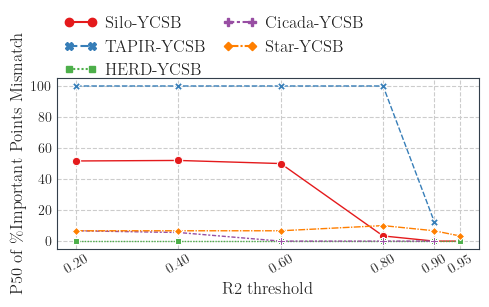

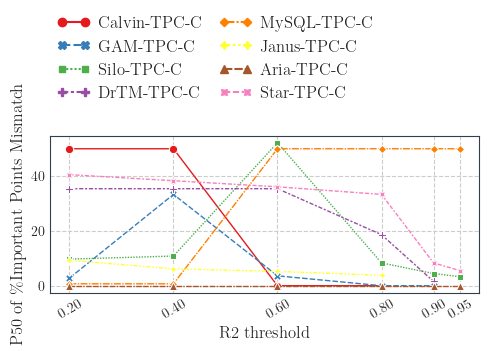

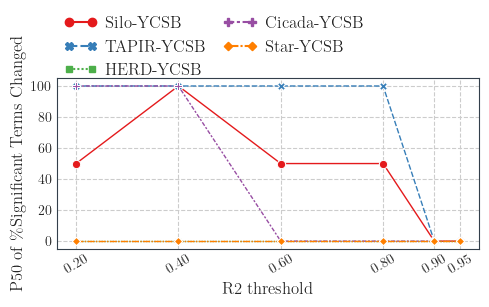

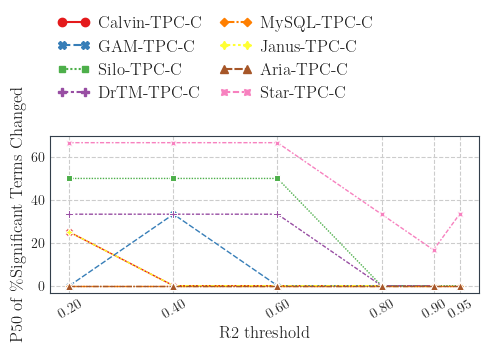

In [42]:
out_base = f"/ANOVA/plots/anova_metric_r2thresh"
if not os.path.exists(out_base):
    os.makedirs(out_base)

fig_size_one = set_size(WIDTH)


for metric in ["num_turning_mismatch","num_of_terms_changed"]:
    for is_ycsb in [True,False]:
        df_subset_idx = df_random_r2t['alg'].apply(lambda x: "YCSB" in x) == is_ycsb
        fig, ax = plt.subplots(1, 1, figsize=fig_size_one,constrained_layout=True)
        sns.lineplot(data=df_random_r2t[df_subset_idx],
                        x="r2_thresh",
                        y= metric ,
                        estimator="median",
                        palette="Set1",
                        errorbar = None,
                        # errorbar=("pi",60), 
                        # err_style="bars",
                        dashes=True, 
                        ax=ax,
                        hue="alg",
                        style = "alg",
                        markers = True,
                        linewidth=1.0)
        ax.set_xticks(r2_thresh_to_examine)
        ax.set_xticklabels([f"{i:.2f}" for i in r2_thresh_to_examine],rotation=30)
        ax.set_xlabel("R2 threshold")
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, borderaxespad=0.,numpoints=2)
        if is_ycsb:
            ax.legend(loc='upper left', bbox_to_anchor=(0., 1.4), ncol=2, borderaxespad=0.,numpoints=2)
        else:
            ax.legend(loc='upper left', bbox_to_anchor=(0., 1.8), ncol=2, borderaxespad=0.,numpoints=2)
        if metric == "num_turning_mismatch":
            ax.set_ylabel("P50 of \%Important Points Mismatch")
        else:
            ax.set_ylabel("P50 of \%Significant Terms Changed")
        if is_ycsb:
            fig.savefig(f"{out_base}/{metric}_ycsb.pdf",bbox_inches = 'tight',dpi=100,format='pdf')
        else:
            fig.savefig(f"{out_base}/{metric}_tpc-c.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

# fig.savefig(f"{out_base}/anova_r2_unsample.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

In [116]:
df_random_r2t[(df_random_r2t.alg == "MySQL-TPC-C")].pivot_table(index="r2_thresh",values="num_turning_mismatch",aggfunc="median")

,num_turning_mismatch
r2_thresh,
0.20,0.0
0.40,0.0
0.60,0.0
0.80,0.0
0.90,0.0
0.95,0.0


In [46]:
r2_unsamples.max()

alg              Calvin(original)-TPC-C
sample_method               calvin-comp
sample_ratio                       0.95
random                                9
r2_unsample                    0.999983
dtype: object

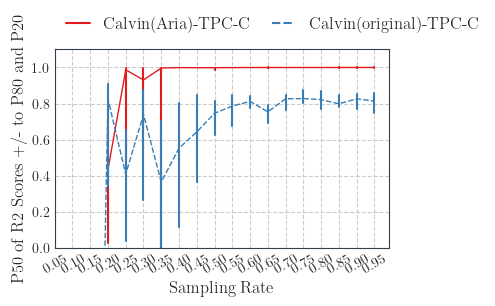

In [48]:
df_calvin_comp = preprocess_result("calvin-comp")
# df_calvin_comp = df_calvin_comp[df_calvin_comp['sample_ratio'] > 0.15]
out_base = f"/ANOVA/plots/anova_r2"
if not os.path.exists(out_base):
    os.makedirs(out_base)

fig_size_one = set_size(WIDTH)
r2_unsamples = df_calvin_comp.groupby(by=["alg","sample_method","sample_ratio","random"])["r2_unsample"].min().reset_index()

# fig, axs = plt.subplots(4, 3, figsize=(fig_size_one[0]*3,fig_size_one[1]*4),constrained_layout=True)
x_labels = [f"{i:.2f}" for i in np.arange(0.05, 1, 0.05)]
    # ax = axs[idx//3][idx%3]
fig, ax = plt.subplots(1, 1, figsize=fig_size_one,constrained_layout=True)

sns.lineplot(data=r2_unsamples,
                x="sample_ratio",
                y="r2_unsample",
                estimator="median",
                palette="Set1",
                errorbar=("pi",60), 
                err_style="bars",
                ax=ax,
                dashes=True, 
                hue="alg",
                style = "alg",
                ms = 1, mew = 2, 
                linewidth=1.0)
ax.set_xticks(np.arange(0.05, 1, 0.05))
ax.set_xticklabels(x_labels,rotation=30)
ax.set_ylim([0,1.1])
ax.set_xlabel("Sampling Rate")
ax.set_ylabel("P50 of R2 Scores +/- to P80 and P20")
ax.legend(loc='upper left', bbox_to_anchor=(0., 1.1, 0, .102), ncol=2, borderaxespad=0.,numpoints=2)
fig.savefig(f"{out_base}/calvin-comp.pdf",bbox_inches = 'tight',dpi=100,format='pdf')